## **Анализ причин увольнения сотрудников образовательных учреждений Квинсленда**

В рамках проекта проведён анализ данных опросов сотрудников двух государственных образовательных учреждений Квинсленда, Австралия: Департамента образования, профессиональной подготовки и занятости (DETE) и Института технического и профессионального образования (TAFE). Основная цель исследования – определить, связана ли неудовлетворённость работой с решением об увольнении по собственному желанию, с учётом различий в стаже и возрастных группах сотрудников. Полученные результаты могут помочь организациям выявить проблемные аспекты рабочей среды и улучшить условия труда для повышения удержания персонала.

In [1]:
#Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
%matplotlib inline

Изучим наборы данных с результатами опросов сотрудников. Известно, что пропущенные значения обозначены как `Not Stated`. Используем это, чтобы заменить их на `NaN` при создании датафрейма:

In [2]:
df1 = pd.read_csv('dete_survey.csv', na_values = ['Not Stated']) 
df2 = pd.read_csv('tafe_survey.csv')

In [3]:
df1.head(3)

,ID,SeparationType,Cease Date,DETE Start Date,Role Start Date,Position,Classification,Region,Business Unit,Employment Status,...,Kept informed,Wellness programs,Health & Safety,Gender,Age,Aboriginal,Torres Strait,South Sea,Disability,NESB
0,1,Ill Health Retirement,08/2012,1984.0,2004.0,Public Servant,A01-A04,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,N,N,N,Male,56-60,NaN,NaN,NaN,NaN,Yes
1,2,Voluntary Early Retirement (VER),08/2012,NaN,NaN,Public Servant,AO5-AO7,Central Office,Corporate Strategy and Peformance,Permanent Full-time,...,N,N,N,Male,56-60,NaN,NaN,NaN,NaN,NaN
2,3,Voluntary Early Retirement (VER),05/2012,2011.0,2011.0,Schools Officer,NaN,Central Office,Education Queensland,Permanent Full-time,...,N,N,N,Male,61 or older,NaN,NaN,NaN,NaN,NaN


In [4]:
df2.head(3)

,Record ID,Institute,WorkArea,CESSATION YEAR,Reason for ceasing employment,Contributing Factors. Career Move - Public Sector,Contributing Factors. Career Move - Private Sector,Contributing Factors. Career Move - Self-employment,Contributing Factors. Ill Health,Contributing Factors. Maternity/Family,...,Workplace. Topic:Does your workplace promote a work culture free from all forms of unlawful discrimination?,Workplace. Topic:Does your workplace promote and practice the principles of employment equity?,Workplace. Topic:Does your workplace value the diversity of its employees?,Workplace. Topic:Would you recommend the Institute as an employer to others?,Gender. What is your Gender?,CurrentAge. Current Age,Employment Type. Employment Type,Classification. Classification,LengthofServiceOverall. Overall Length of Service at Institute (in years),LengthofServiceCurrent. Length of Service at current workplace (in years)
0,6.341330e+17,Southern Queensland Institute of TAFE,Non-Delivery (corporate),2010.0,Contract Expired,NaN,NaN,NaN,NaN,NaN,...,Yes,Yes,Yes,Yes,Female,26 30,Temporary Full-time,Administration (AO),1-2,1-2
1,6.341337e+17,Mount Isa Institute of TAFE,Non-Delivery (corporate),2010.0,Retirement,-,-,-,-,-,...,Yes,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN
2,6.341388e+17,Mount Isa Institute of TAFE,Delivery (teaching),2010.0,Retirement,-,-,-,-,-,...,Yes,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN


Удалим из обоих датафреймов столбцы, которые представляют наименьшую ценность для дальнейшего исследования. В основном они содержат подробные оценки сотрудников по отдельным аспектам работы, связанным с возможностями личностного роста, атмосферой в коллективе и индивидуальными пожеланиями. Данные показатели отражают субъективное восприятие сотрудниками условий работы и не являются ключевыми для определения причин ухода. Их удаление позволит сосредоточиться на наиболее значимых признаках и упростить последующую обработку и интерпретацию данных:

In [5]:
df1 = df1.drop(df1.columns[28:49], axis = 1)
df2 = df2.drop(df2.columns[17:66], axis = 1)

Перед дальнейшей обработкой стандартизируем названия столбцов и приведем их к единому формату. Также известно, что некоторые столбцы содержат одинаковые данные, но имеют разные названия, поэтому необходимо заранее устранить эти различия для корректного последующего анализа:

In [6]:
print(df1.columns)
print(df2.columns)

Index(['ID', 'SeparationType', 'Cease Date', 'DETE Start Date',
       'Role Start Date', 'Position', 'Classification', 'Region',
       'Business Unit', 'Employment Status', 'Career move to public sector',
       'Career move to private sector', 'Interpersonal conflicts',
       'Job dissatisfaction', 'Dissatisfaction with the department',
       'Physical work environment', 'Lack of recognition',
       'Lack of job security', 'Work location', 'Employment conditions',
       'Maternity/family', 'Relocation', 'Study/Travel', 'Ill Health',
       'Traumatic incident', 'Work life balance', 'Workload',
       'None of the above', 'Gender', 'Age', 'Aboriginal', 'Torres Strait',
       'South Sea', 'Disability', 'NESB'],
      dtype='object')
Index(['Record ID', 'Institute', 'WorkArea', 'CESSATION YEAR',
       'Reason for ceasing employment',
       'Contributing Factors. Career Move - Public Sector ',
       'Contributing Factors. Career Move - Private Sector ',
       'Contributing Fact

Внесём изменения в названия столбцов первого датафрейма, приведя их к стилю snake_case:

In [7]:
pattern = r"[ /]"
df1.columns = df1.columns.str.lower().str.strip().str.replace(pattern, "_", regex = True)

Для столбцов второго датафрейма необходимо переименовать отдельные столбцы, чтобы при последующем объединении избежать появления ошибочных пропусков:

In [8]:
df2.rename({'Record ID': 'id',
            'CESSATION YEAR': 'cease_date',
            'Reason for ceasing employment': 'separationtype',
            'Gender. What is your Gender?': 'gender',
            'CurrentAge. Current Age': 'age',
            'Employment Type. Employment Type': 'employment_status',
            'Classification. Classification': 'position',
            'LengthofServiceOverall. Overall Length of Service at Institute (in years)': 'institute_service',
            'LengthofServiceCurrent. Length of Service at current workplace (in years)': 'role_service'}, 
             axis = 1, inplace = True)

In [9]:
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   822 non-null    int64  
 1   separationtype                       822 non-null    object 
 2   cease_date                           788 non-null    object 
 3   dete_start_date                      749 non-null    float64
 4   role_start_date                      724 non-null    float64
 5   position                             817 non-null    object 
 6   classification                       455 non-null    object 
 7   region                               717 non-null    object 
 8   business_unit                        126 non-null    object 
 9   employment_status                    817 non-null    object 
 10  career_move_to_public_sector         822 non-null    bool   
 11  career_move_to_private_sector   

Рассмотрим уникальные значения в столбце `separationtype`, который содержится в обоих датафреймах. Данный столбец обозначает причину увольнения сотрудников:

In [10]:
df1['separationtype'].value_counts()

separationtype
Age Retirement                          285
Resignation-Other reasons               150
Resignation-Other employer               91
Resignation-Move overseas/interstate     70
Voluntary Early Retirement (VER)         67
Ill Health Retirement                    61
Other                                    49
Contract Expired                         34
Termination                              15
Name: count, dtype: int64

In [11]:
df2['separationtype'].value_counts()

separationtype
Resignation                 340
Contract Expired            127
Retrenchment/ Redundancy    104
Retirement                   82
Transfer                     25
Termination                  23
Name: count, dtype: int64

Поскольку для нашего анализа важны именно увольнения по собственному желанию, для обоих датафреймов оставим только те строки, в которых в столбце `separationtype` содержится подстрока `Resignation`:

In [12]:
pattern = r"resignation ?" #Регулярное выражение для поиска вхождений подстроки resignation в столбце separationtype
df1_resignation_mask = df1['separationtype'].str.lower().str.contains(pattern, na = False, regex = True)
df2_resignation_mask = df2['separationtype'].str.lower().str.contains(pattern, na = False, regex = True)

dete_resignations = df1[df1_resignation_mask].copy()
tafe_resignations = df2[df2_resignation_mask].copy()

На текущем этапе сосредоточимся на проверке корректности годов, указанных в столбцах `cease_date` и `dete_start_date`, содержащих даты начала и окончания работы в датафрейме `dete_resignations`:

In [13]:
dete_resignations['cease_date'].unique()

array(['05/2012', '07/2012', '2012', '2013', '2010', '07/2013', '06/2013',
       '09/2013', '09/2010', '01/2014', '05/2013', '08/2013', '10/2013',
       '12/2013', '11/2013', nan, '07/2006'], dtype=object)

In [14]:
dete_resignations['dete_start_date'].unique()

array([2005., 1994., 2009., 1997., 1998., 2007.,   nan, 1982., 1980.,
       1973., 1995., 2003., 2006., 2011., 1977., 1974., 1976., 1993.,
       2008., 1986., 2002., 2004., 2010., 2012., 1989., 1999., 1996.,
       2000., 1991., 1992., 2001., 1988., 1990., 1985., 1963., 2013.,
       1972., 1983., 1971., 1984., 1975., 1987.])

На первый взгляд, отдельные значения годов выглядят адекватно и не содержат аномалий. Извлечём их из строковых значений и проверим попарно:

In [15]:
pattern = r"([1-2][0-9]{3})" #Регулярное выражение для поиска года в строке

dete_resignations['cease_date'] = dete_resignations['cease_date'].str.extract(pattern)
dete_resignations['cease_date'] = dete_resignations['cease_date'].astype(float)

dete_resignations[['cease_date','dete_start_date']].describe()

,cease_date,dete_start_date
count,300.00000,283.000000
mean,2012.60000,2002.067138
std,0.75403,9.914479
min,2006.00000,1963.000000
25%,2012.00000,1997.000000
50%,2013.00000,2005.000000
75%,2013.00000,2010.000000
max,2014.00000,2013.000000


Все значения являются корректными, однако это не исключает вероятность наличия логических ошибок, при которых год начала работы может быть больше года окончания. Проверим это:

In [16]:
dete_resignations.loc[dete_resignations['dete_start_date'] > dete_resignations['cease_date'], ['cease_date','dete_start_date']]

,cease_date,dete_start_date


Как видим, такие записи отсутствуют. Также проверим данные с датами в столбце `cease_date` датафрейма `tafe_resignations`:

In [17]:
tafe_resignations['cease_date'].unique()

array([2010., 2009.,   nan, 2011., 2012., 2013.])

In [18]:
tafe_resignations['cease_date'].describe()

count     335.000000
mean     2011.394030
std         1.005952
min      2009.000000
25%      2011.000000
50%      2011.000000
75%      2012.000000
max      2013.000000
Name: cease_date, dtype: float64

Все значения годов находятся в норме. Для дальнейшего анализа необходимо рассчитать стаж сотрудников. К сожалению, данные не представлены в формате, позволяющем корректно преобразовать их в datetime и получить более точное значение стажа с использованием объекта timedelta. Поэтому в дальнейшем мы будем работать только с разницей между годами.

In [19]:
dete_resignations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 311 entries, 3 to 821
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   311 non-null    int64  
 1   separationtype                       311 non-null    object 
 2   cease_date                           300 non-null    float64
 3   dete_start_date                      283 non-null    float64
 4   role_start_date                      271 non-null    float64
 5   position                             308 non-null    object 
 6   classification                       161 non-null    object 
 7   region                               265 non-null    object 
 8   business_unit                        32 non-null     object 
 9   employment_status                    307 non-null    object 
 10  career_move_to_public_sector         311 non-null    bool   
 11  career_move_to_private_sector        

---

Напомним, что наша конечная цель – ответить на следующий вопрос: 

> Увольняются ли сотрудники, проработавшие в институтах недолго, из-за неудовлетворенности работой? А как насчет сотрудников, проработавших дольше? 

Из-за особенности имеющихся данных, представленных только в виде годов, нам придётся ограничиться менее точной оценкой стажа, так как для сотрудников, начавших и завершивших работу в одном году, рассчитанный стаж будет равен 0. Таким образом, в общем виде данные будут разделены на две группы: 

- сотрудники, проработавшие менее года;
- сотрудники, проработавшие более года.

In [20]:
#Создадим новый столбец, обозначающий стаж сотрудника
dete_resignations['institute_service'] = dete_resignations['cease_date'] - dete_resignations['dete_start_date']
dete_resignations['institute_service'].head(5)

3      7.0
5     18.0
8      3.0
9     15.0
11     3.0
Name: institute_service, dtype: float64

Мы создали новый столбец `institute_service`, который в дальнейшем будем использовать для анализа респондентов опроса в зависимости от их стажа работы.

Далее определим сотрудников, уволившихся по собственному желанию. На основе указанных ими причин выделим наиболее значимые признаки, связанные с неудовлетворенностью работой. Начнём с датафрейма `tafe_resignations`:

In [21]:
tafe_resignations.columns

Index(['id', 'Institute', 'WorkArea', 'cease_date', 'separationtype',
       'Contributing Factors. Career Move - Public Sector ',
       'Contributing Factors. Career Move - Private Sector ',
       'Contributing Factors. Career Move - Self-employment',
       'Contributing Factors. Ill Health',
       'Contributing Factors. Maternity/Family',
       'Contributing Factors. Dissatisfaction',
       'Contributing Factors. Job Dissatisfaction',
       'Contributing Factors. Interpersonal Conflict',
       'Contributing Factors. Study', 'Contributing Factors. Travel',
       'Contributing Factors. Other', 'Contributing Factors. NONE', 'gender',
       'age', 'employment_status', 'position', 'institute_service',
       'role_service'],
      dtype='object')

Для дальнейшего анализа выберем следующие столбцы:

- `Contributing Factors. Job Dissatisfaction`: указывает, являлась ли неудовлетворённость работой причиной увольнения сотрудника.
- `Contributing Factors. Dissatisfaction`: отражает наличие общего недовольства сотрудника условиями или отдельными аспектами работы.
- `Contributing Factors. Ill Health`: показывает, было ли ухудшение здоровья одной из причин увольнения.
- `Contributing Factors. Interpersonal Conflict`: указывает, были ли конфликты с коллегами или руководством фактором, повлиявшим на решение об увольнении.

In [22]:
tafe_resignations['Contributing Factors. Job Dissatisfaction'].value_counts(dropna = False)

Contributing Factors. Job Dissatisfaction
-                      270
Job Dissatisfaction     62
NaN                      8
Name: count, dtype: int64

In [23]:
tafe_resignations['Contributing Factors. Dissatisfaction'].value_counts(dropna = False)

Contributing Factors. Dissatisfaction
-                                         277
Contributing Factors. Dissatisfaction      55
NaN                                         8
Name: count, dtype: int64

In [24]:
tafe_resignations['Contributing Factors. Ill Health'].value_counts(dropna = False)

Contributing Factors. Ill Health
-             311
Ill Health     21
NaN             8
Name: count, dtype: int64

In [25]:
tafe_resignations['Contributing Factors. Interpersonal Conflict'].value_counts(dropna = False)

Contributing Factors. Interpersonal Conflict
-                         308
Interpersonal Conflict     24
NaN                         8
Name: count, dtype: int64

Внесём изменения в названия данных столбцов и остальных признаков для удобства дальнейшей работы и корректного объединения:

In [26]:
tafe_resignations.rename({'Contributing Factors. Job Dissatisfaction': 'job_dissatisfaction',
                          'Contributing Factors. Dissatisfaction': 'dissatisfaction',
                          'Contributing Factors. Ill Health': 'ill_health',
                          'Contributing Factors. Interpersonal Conflict' : 'interpersonal_conflicts',
                          'Contributing Factors. Study': 'study',
                          'Contributing Factors. Travel': 'travel',
                          'Contributing Factors. Career Move - Public Sector ': 'career_move_to_public_sector',
                          'Contributing Factors. Career Move - Private Sector ': 'career_move_to_private_sector',
                          'Contributing Factors. Maternity/Family': 'maternity_family',
                          'Contributing Factors. NONE': 'none_of_the_above'},
                           axis = 1, inplace = True)

Создадим функцию `update_vals()` для преобразования столбцов с причинами увольнения в булевый формат: 

Значения `-` (как несоответствие) заменяем на `False`, указанные причины – на `True`, а пропущенные значения (NaN) оставим без изменений:

In [27]:
def update_vals(value):
    result = True 
    if value == '-': #Заменяем - на False, т.к. - означает, что причина ухода не подходит
        result = False
    elif pd.isnull(value): #Пропущенные значения остаются без изменений
        result = np.nan
    return result

Применим функцию к выбранным столбцам:

In [28]:
tafe_resignations_columns = ['job_dissatisfaction',
                             'dissatisfaction',
                             'ill_health',
                             'interpersonal_conflicts',
                             'study',
                             'travel',
                             'career_move_to_public_sector',
                             'career_move_to_private_sector',
                             'maternity_family',
                             'none_of_the_above'
                            ]

tafe_resignations[tafe_resignations_columns] = tafe_resignations[tafe_resignations_columns].map(update_vals)

Создадим новый столбец `dissatisfied`, который будет содержать сумму значений признаков, наиболее связанных с неудовлетворенностью работой:

In [29]:
tafe_resignations['dissatisfied'] = tafe_resignations[['job_dissatisfaction', 'dissatisfaction', 'ill_health', 'interpersonal_conflicts']].sum(axis = 1)
tafe_resignations['dissatisfied'].value_counts()

dissatisfied
0    230
1     71
2     27
3     11
4      1
Name: count, dtype: int64

Исходя из полученных результатов, большинство увольнений по собственному желанию не связано с состоянием здоровья, неудовлетворённостью работой или конфликтами в коллективе. Однако также существуют случаи, когда на решение об увольнении повлияло сразу несколько факторов: у 11 сотрудников было выявлено по 3 причины, а у 1 сотрудника – сразу 4. Более подробно рассмотрим эти случаи на следующих этапах анализа. 

Далее перейдём к изучению причин увольнения в датафрейме `dete_resignations`:

In [30]:
dete_resignations.columns

Index(['id', 'separationtype', 'cease_date', 'dete_start_date',
       'role_start_date', 'position', 'classification', 'region',
       'business_unit', 'employment_status', 'career_move_to_public_sector',
       'career_move_to_private_sector', 'interpersonal_conflicts',
       'job_dissatisfaction', 'dissatisfaction_with_the_department',
       'physical_work_environment', 'lack_of_recognition',
       'lack_of_job_security', 'work_location', 'employment_conditions',
       'maternity_family', 'relocation', 'study_travel', 'ill_health',
       'traumatic_incident', 'work_life_balance', 'workload',
       'none_of_the_above', 'gender', 'age', 'aboriginal', 'torres_strait',
       'south_sea', 'disability', 'nesb', 'institute_service'],
      dtype='object')

Для дальнейшего анализа выберем следующие столбцы:
- `job_dissatisfaction`: указывает, была ли неудовлетворённость самой работой причиной увольнения.
- `dissatisfaction_with_the_department`: отражает недовольство сотрудника конкретным подразделением или отделом.
- `physical_work_environment`: показывает неудовлетворённость физическими условиями труда (например, офис, оборудование).
- `lack_of_recognition`: обозначает отсутствие признания и оценки заслуг сотрудника.
- `lack_of_job_security`: указывает на беспокойства по поводу стабильности и безопасности рабочего места.
- `work_location`:  отражает недовольство местоположением работы или возможными переездами.
- `employment_conditions`: показывает недовольство общими условиями труда (график, оплата, льготы и т.д.).
- `work_life_balance`: указывает на проблемы с балансом между работой и личной жизнью. 
- `workload`: отражает недовольство объёмом или распределением рабочей нагрузки.
- `ill_health`: показывает, было ли ухудшение здоровья одной из причин увольнения.
- `interpersonal_conflicts`: указывает, были ли конфликты с коллегами или руководством фактором, повлиявшим на решение об увольнении.

In [31]:
dete_resignations['job_dissatisfaction'].value_counts(dropna = False)

job_dissatisfaction
False    270
True      41
Name: count, dtype: int64

In [32]:
dete_resignations['dissatisfaction_with_the_department'].value_counts(dropna = False)

dissatisfaction_with_the_department
False    282
True      29
Name: count, dtype: int64

In [33]:
dete_resignations['physical_work_environment'].value_counts(dropna = False)

physical_work_environment
False    305
True       6
Name: count, dtype: int64

In [34]:
dete_resignations['lack_of_recognition'].value_counts(dropna = False)

lack_of_recognition
False    278
True      33
Name: count, dtype: int64

In [35]:
dete_resignations['lack_of_job_security'].value_counts(dropna = False)

lack_of_job_security
False    297
True      14
Name: count, dtype: int64

In [36]:
dete_resignations['work_location'].value_counts(dropna = False)

work_location
False    293
True      18
Name: count, dtype: int64

In [37]:
dete_resignations['employment_conditions'].value_counts(dropna = False)

employment_conditions
False    288
True      23
Name: count, dtype: int64

In [38]:
dete_resignations['work_life_balance'].value_counts(dropna = False)

work_life_balance
False    243
True      68
Name: count, dtype: int64

In [39]:
dete_resignations['workload'].value_counts(dropna = False)

workload
False    284
True      27
Name: count, dtype: int64

In [40]:
dete_resignations['ill_health'].value_counts(dropna = False)

ill_health
False    292
True      19
Name: count, dtype: int64

In [41]:
dete_resignations['interpersonal_conflicts'].value_counts(dropna = False)

interpersonal_conflicts
False    291
True      20
Name: count, dtype: int64

Исходя из полученных результатов, ни один из выбранных столбцов не содержит пропущенных значений. Поскольку все выбранные признаки представлены в булевом формате, создадим результирующий столбец с суммой всех причин увольнения:

In [42]:
dete_resignations_columns = ['job_dissatisfaction',
                             'dissatisfaction_with_the_department',
                             'physical_work_environment',
                             'lack_of_recognition',
                             'lack_of_job_security',
                             'work_location',
                             'employment_conditions',
                             'work_life_balance',
                             'workload',
                             'ill_health',
                             'interpersonal_conflicts']

dete_resignations['dissatisfied'] = dete_resignations[dete_resignations_columns].sum(axis = 1)
dete_resignations['dissatisfied'].value_counts().sort_index()

dissatisfied
0    146
1     82
2     48
3     27
4      5
5      1
6      1
8      1
Name: count, dtype: int64

Как и в предыдущем случае, большинство сотрудников увольняются по причинам, не связанным с проблемами на работе.

---

На данном этапе необходимо объединить датафреймы. Чтобы после объединения можно было определить, к какому институту относился опрошенный сотрудник, создадим в обоих датафреймах столбец `institute`, содержащий идентификатор организации (`DETE` или `TAFE`). 

In [43]:
dete_resignations['institute'] = 'DETE'
tafe_resignations['institute'] = 'TAFE'

В обоих датафреймах всё ещё присутствуют признаки, относящиеся к одним и тем же категориям, но представленные по-разному. Например, в `dete_resignations` факторы, связанные с учёбой или путешествиями, объединены в одном столбце `study_travel`, тогда как в `tafe_resignations` они разделены на два отдельных признака – `study` и `travel`. Данные различия в представлении были обнаружены уже после предыдущего этапа переименования. Для корректного объединения необходимо привести их к единому формату, чтобы избежать появления лишних пропусков. Дополнительно удалим признаки, которые не требуются для дальнейшего анализа:

In [44]:
tafe_resignations['study'].value_counts(dropna = False)

study
False    316
True      16
NaN        8
Name: count, dtype: int64

In [45]:
tafe_resignations['travel'].value_counts(dropna = False)

travel
False    315
True      17
NaN        8
Name: count, dtype: int64

In [46]:
tafe_resignations['study_travel'] = tafe_resignations['study'] | tafe_resignations['travel']
tafe_resignations = tafe_resignations.drop(['study',
                                            'travel',
                                            'Institute',
                                            'Contributing Factors. Career Move - Self-employment',
                                            'Contributing Factors. Other'], axis = 1)

combined = pd.concat([dete_resignations, tafe_resignations], ignore_index = True)

После объединения датафреймов в ряде столбцов появились пропущенные значения. Визуализируем их с помощью тепловой карты, чтобы определить, какие признаки следует исключить из дальнейшего анализа из-за большого количества пропусков:

In [47]:
combined.notnull().sum()

id                                     651
separationtype                         651
cease_date                             635
dete_start_date                        283
role_start_date                        271
position                               598
classification                         161
region                                 265
business_unit                           32
employment_status                      597
career_move_to_public_sector           643
career_move_to_private_sector          643
interpersonal_conflicts                643
job_dissatisfaction                    643
dissatisfaction_with_the_department    311
physical_work_environment              311
lack_of_recognition                    311
lack_of_job_security                   311
work_location                          311
employment_conditions                  311
maternity_family                       643
relocation                             311
study_travel                           651
ill_health 

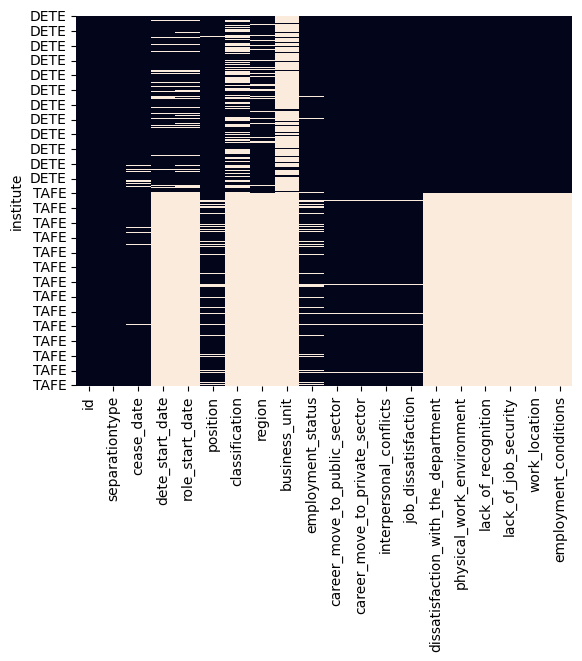

In [48]:
heatmap_combined = combined.set_index('institute')
sns.heatmap(heatmap_combined.iloc[:, :-20].isnull(), cbar = False)
plt.show()

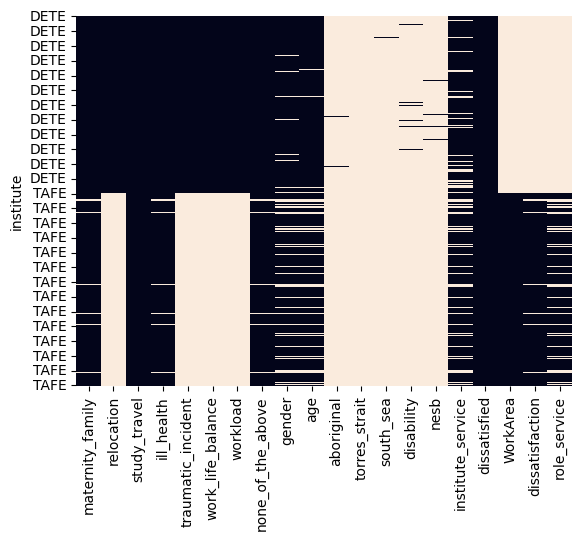

In [49]:
sns.heatmap(heatmap_combined.iloc[:, 20:].isnull(), cbar = False)
plt.show()

Для начала удалим столбцы, в которых практически полностью отсутствуют данные (`classification`, `business_unit`, `aboriginal`, `torres_strait`, `south_sea`, `disability`, `nesb`):

In [50]:
combined = combined.dropna(axis = 1, thresh = 272) #Минимальный порог для корректного удаления выбранных столбцов
combined.isnull().sum()

id                                       0
separationtype                           0
cease_date                              16
dete_start_date                        368
position                                53
employment_status                       54
career_move_to_public_sector             8
career_move_to_private_sector            8
interpersonal_conflicts                  8
job_dissatisfaction                      8
dissatisfaction_with_the_department    340
physical_work_environment              340
lack_of_recognition                    340
lack_of_job_security                   340
work_location                          340
employment_conditions                  340
maternity_family                         8
relocation                             340
study_travel                             0
ill_health                               8
traumatic_incident                     340
work_life_balance                      340
workload                               340
none_of_the

---

Теперь, когда датафреймы объединены, мы практически готовы к проведению анализа. Однако перед этим необходимо привести столбец `institute_service` к единому формату, поскольку после объединения он содержит данные в разных представлениях:

- в `dete_resignations` стаж был рассчитан как разность между годом окончания и годом начала работы;
- в `tafe_resignations` стаж представлен в трёх форматах: числом, интервалом (например, `5–6`) и строковыми значениями (`Less than 1 year` и `More than 20 years`).

Для корректного анализа приведём все значения к единому виду. Для интервалов будем использовать их среднее значение, а строковые обозначения заменим следующим образом:

- `Less than 1 year` на 0, поскольку в первом датафрейме сотрудники, проработавшие менее года, также имели стаж, равный 0;
- `More than 20 years` заменим на 21, используя это значение в качестве условного обозначения стажа свыше 20 лет.

In [51]:
combined['institute_service'].unique()

array([7.0, 18.0, 3.0, 15.0, 14.0, 5.0, nan, 30.0, 32.0, 39.0, 17.0, 9.0,
       6.0, 1.0, 35.0, 38.0, 36.0, 19.0, 4.0, 26.0, 10.0, 8.0, 2.0, 0.0,
       23.0, 13.0, 16.0, 12.0, 21.0, 20.0, 24.0, 33.0, 22.0, 28.0, 49.0,
       11.0, 41.0, 27.0, 42.0, 25.0, 29.0, 34.0, 31.0, '3-4', '7-10',
       '1-2', 'Less than 1 year', '11-20', '5-6', 'More than 20 years'],
      dtype=object)

Для начала обработаем значения, представленные в виде интервалов:

In [52]:
interval_mask = combined['institute_service'].str.contains('-', na = False)

pattern = r"(?P<first_number>[0-9]?[0-9])-(?P<second_number>[0-9][0-9]?)"
interval_numbers = combined.loc[interval_mask, 'institute_service'].str.extract(pattern)
interval_numbers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 207 entries, 312 to 650
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   first_number   207 non-null    object
 1   second_number  207 non-null    object
dtypes: object(2)
memory usage: 4.9+ KB


In [53]:
interval_numbers[['first_number','second_number']].value_counts()

first_number  second_number
1             2                64
3             4                63
5             6                33
11            20               26
7             10               21
Name: count, dtype: int64

Все интервалы были извлечены корректно и совпадают со значениями, полученными ранее с помощью метода unique(). Рассчитаем для них среднее значение и заменим интервальные значения в столбце `institute_service` по маске `interval_mask`:

In [54]:
interval_numbers['first_number'] = interval_numbers['first_number'].astype(float)
interval_numbers['second_number'] = interval_numbers['second_number'].astype(float)
interval_numbers['mean_number'] = (interval_numbers['first_number'] + interval_numbers['second_number']) / 2
interval_numbers.head(2)

,first_number,second_number,mean_number
312,3.0,4.0,3.5
313,7.0,10.0,8.5


In [55]:
combined.loc[interval_mask, 'institute_service'] = interval_numbers['mean_number']

Теперь обработаем строковые значения – `Less than 1 year` и `More than 20 years`:

In [56]:
combined.loc[combined['institute_service'] == 'Less than 1 year', 'institute_service'] = 0
combined.loc[combined['institute_service'] == 'More than 20 years', 'institute_service'] = 21

Проверим полученные после обработки значения:

In [57]:
combined['institute_service'].unique()

array([7.0, 18.0, 3.0, 15.0, 14.0, 5.0, nan, 30.0, 32.0, 39.0, 17.0, 9.0,
       6.0, 1.0, 35.0, 38.0, 36.0, 19.0, 4.0, 26.0, 10.0, 8.0, 2.0, 0.0,
       23.0, 13.0, 16.0, 12.0, 21.0, 20.0, 24.0, 33.0, 22.0, 28.0, 49.0,
       11.0, 41.0, 27.0, 42.0, 25.0, 29.0, 34.0, 31.0, 3.5, 8.5, 1.5,
       15.5, 5.5], dtype=object)

Для дальнейшего анализа преобразуем числовые значения стажа в категориальные признаки. Будем использовать следующие категории:

- `New`: начинающий сотрудник – менее 3 лет в организации;
- `Experienced`: опытный сотрудник – от 3 до 6 лет;
- `Established`: устойчивый сотрудник – от 7 до 10 лет;
- `Veteran`: долгосрочный сотрудник – 11 и более лет.

Для этого создадим функцию `career_stage()`, которая будет присваивать каждому сотруднику соответствующую категорию в зависимости от его стажа:

In [58]:
def career_stage(value):
    result = np.nan
    if value < 3:
        result = 'New'
    elif 3 <= value <= 6:
        result = 'Experienced'
    elif 7 <= value <= 10:
        result = 'Established'
    elif value >= 11:
        result = 'Veteran'
        
    return result

Применим её для создания нового столбца `service_cat`, содержащего категорию стажа сотрудника:

In [59]:
combined['service_cat'] = combined['institute_service'].map(career_stage)
combined['service_cat'].value_counts(dropna = False)

service_cat
New            193
Experienced    172
Veteran        136
NaN             88
Established     62
Name: count, dtype: int64

Визуализируем распределение участников опроса по институтам:

In [60]:
combined_group_institute = combined[combined['dissatisfied'] > 0].groupby('institute').size()
combined_group_institute

institute
DETE    165
TAFE    110
dtype: int64

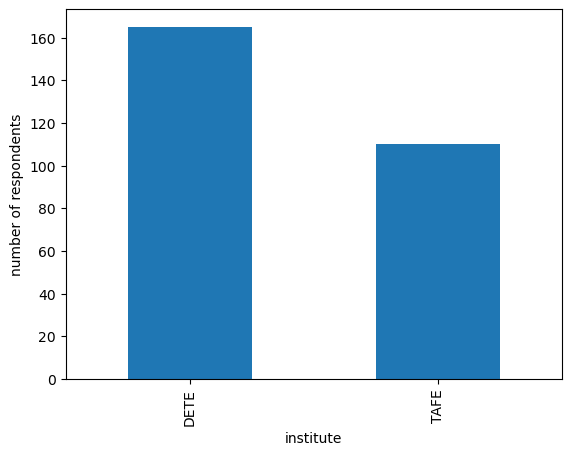

In [61]:
combined_group_institute.plot(kind = 'bar', ylabel = 'number of respondents')
plt.show()

По столбчатой диаграмме видно, что количество участников из института `DETE` выше, чем из `TAFE` и составляет `165` и `110` человек соответственно. Несмотря на различие в `55` наблюдений, размеры выборок остаются сопоставимыми, что позволяет проводить дальнейший сравнительный анализ.

---

Для последующей визуализации преобразуем датафрейм из широкого формата в длинный с помощью метода `melt()`. Это позволит представить выбранные причины увольнения в виде отдельных строк, что упростит их группировку, агрегацию и построение сравнительных визуализаций:

In [62]:
columns_for_melt = [
  'job_dissatisfaction',
  'dissatisfaction_with_the_department',
  'physical_work_environment',
  'lack_of_recognition',
  'lack_of_job_security',
  'work_location',
  'employment_conditions',
  'work_life_balance',
  'workload',
  'dissatisfaction',
  'ill_health',
  'interpersonal_conflicts',
]

combined_melt_reasons = pd.melt(combined, id_vars = ['institute'], value_vars = columns_for_melt)
combined_melt_reasons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7812 entries, 0 to 7811
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   institute  7812 non-null   object
 1   variable   7812 non-null   object
 2   value      4749 non-null   object
dtypes: object(3)
memory usage: 183.2+ KB


Из полученного после применения `melt()` датафрейма выделим данные для каждого института (`DETE` и `TAFE`). Затем с помощью `pivot_table()` сгруппируем их по причинам увольнения, рассчитав для каждой из них общее количество упоминаний с использованием агрегирующей функции `sum()`:

In [63]:
TAFE_melt_reasons = combined_melt_reasons[combined_melt_reasons['institute'] == 'TAFE']
DETE_melt_reasons = combined_melt_reasons[combined_melt_reasons['institute'] == 'DETE']

TAFE_reasons_pivot = TAFE_melt_reasons.pivot_table(index = 'variable', values = 'value', aggfunc = 'sum')
DETE_reasons_pivot = DETE_melt_reasons.pivot_table(index = 'variable', values = 'value', aggfunc = 'sum')

print(TAFE_reasons_pivot)

                                    value
variable                                 
dissatisfaction                        55
dissatisfaction_with_the_department     0
employment_conditions                   0
ill_health                             21
interpersonal_conflicts                24
job_dissatisfaction                    62
lack_of_job_security                    0
lack_of_recognition                     0
physical_work_environment               0
work_life_balance                       0
work_location                           0
workload                                0


Так как некоторые признаки присутствовали только в одном из исходных наборов данных, после объединения датафреймов для второго института они содержали исключительно пропущенные значения (`NaN`). В результате применения агрегирующей функции `sum()` такие категории получили нулевые значения, поэтому были исключены из дальнейшего сравнения:

In [64]:
TAFE_reasons_pivot = TAFE_reasons_pivot[TAFE_reasons_pivot['value'] != 0]
DETE_reasons_pivot = DETE_reasons_pivot[DETE_reasons_pivot['value'] != 0]

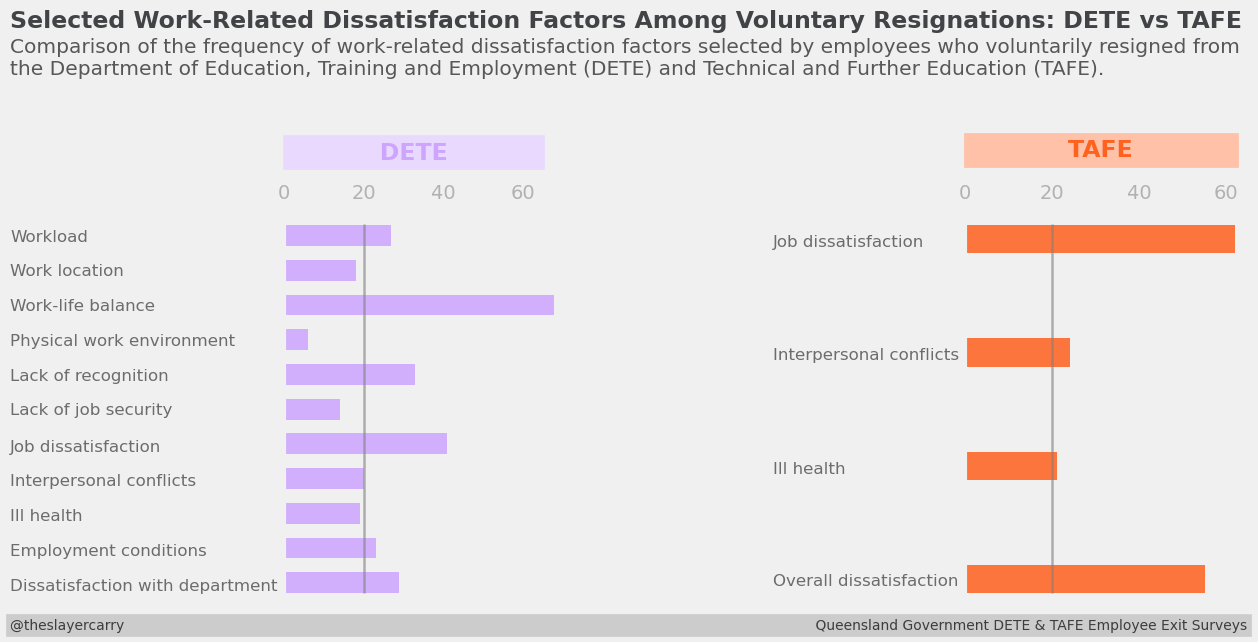

In [65]:
# Для данной визуализации мы будем использовать стиль `fivethirtyeight`
style.use('default')
style.use('fivethirtyeight')

plt.figure(figsize = (15, 5), dpi = 100)

# Первый ряд: Визуализация частотного распределения каждого признака увольнения в зависимости от университета

ax1 = plt.subplot(1, 4, 2)
ax2 = plt.subplot(1, 4, 4)

axes = [ax1, ax2]

ax1.barh(DETE_reasons_pivot.index, DETE_reasons_pivot['value'], height = 0.60, color = '#cda5ff', alpha = 0.86)
ax2.barh(TAFE_reasons_pivot.index, TAFE_reasons_pivot['value'], height = 0.25, color = '#ff611e', alpha = 0.86)

for ax in axes:
    ax.grid(alpha = 0)
    ax.xaxis.tick_top()
    ax.set_yticklabels([])
    #ax.set_xticklabels([])
    #ax.xaxis.grid(False)   # убрать вертикальные линии

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_alpha(0.26)
        
ax1.axvline(x = 20, alpha = 0.6, linewidth = 1.8, color = 'grey', ymin = 0.045, ymax = 0.958)
ax2.axvline(x = 20, alpha = 0.6, linewidth = 1.8, color = 'grey', ymin = 0.045, ymax = 0.958)

# Заголовок
ax1.text(x = -69, y = 16, s = 'Selected Work-Related Dissatisfaction Factors Among Voluntary Resignations: DETE vs TAFE', size = 17, weight = 'bold', color = '#242528', alpha = 0.85)

# Подзаголовок
ax1.text(x = -69, y = 14.65, s = '''Comparison of the frequency of work-related dissatisfaction factors selected by employees who voluntarily resigned from 
the Department of Education, Training and Employment (DETE) and Technical and Further Education (TAFE).''', size = 14.5, color = "#575757")

#Отдельно наносим подписи на оси y для каждого института:
DETE_y_coords = [-0.2, 0.8, 1.8, 2.8, 3.8, 4.85, 5.85, 6.85, 7.85, 8.85, 9.85]
DETE_labels = [
    "Dissatisfaction with department",
    "Employment conditions",
    "Ill health",
    "Interpersonal conflicts",
    "Job dissatisfaction",
    "Lack of job security",
    "Lack of recognition",
    "Physical work environment",
    "Work-life balance",
    "Work location",
    "Workload"
]
TAFE_y_coords = [-0.05, 0.94, 1.94, 2.94]
TAFE_labels = [
    "Overall dissatisfaction",
    "Ill health",
    "Interpersonal conflicts",
    "Job dissatisfaction",
]

for label, y_coord in zip(DETE_labels, DETE_y_coords):
    ax1.text(x = -69, y = y_coord, s = label, size = 12, alpha = 0.55)  
for label, y_coord in zip(TAFE_labels, TAFE_y_coords):
    ax2.text(x = -44, y = y_coord, s = label, size = 12, alpha = 0.55)
    
ax1.set_xticks([0, 20, 40, 60])
ax2.set_xticks([0, 20, 40, 60])

ax1.text(1.25, 12.21, s = " "*11 + "DETE" + 11*" ", color = '#cda5ff', size = 17, weight = 'bold', backgroundcolor = '#ead9ff')
ax2.text(1, 3.73, s = " "*12 + "TAFE" + 12*" ", color = '#ff611e', size = 17, weight = 'bold', backgroundcolor = "#ffc1a7")

#Подпись создателя
ax1.text(-69, -1.33, s = "@theslayercarry" + 158*" " + "Queensland Government DETE & TAFE Employee Exit Surveys", backgroundcolor = '#cccccc', size = 10, alpha = 0.7)

plt.show()

Для построения следующей визуализации сгруппируем данные для каждого института (`DETE` и `TAFE`) *по категориям рабочего стажа* среди сотрудников, указавших хотя бы одну причину недовольства, связанную с работой (`dissatisfied > 0`):

In [66]:
TAFE_category_group = combined[(combined['institute'] == 'TAFE') & (combined['dissatisfied'] > 0)].groupby('service_cat').size()
DETE_category_group = combined[(combined['institute'] == 'DETE') & (combined['dissatisfied'] > 0)].groupby('service_cat').size()

Так как данная визуализация также будет учитывать возрастное распределение сотрудников, следующим этапом необходимо подготовить и сгруппировать данные по возрастным группам:

In [67]:
combined['age'].value_counts()

age
51-55            71
41-45            48
41  45           45
46-50            42
36-40            41
46  50           39
26-30            35
21  25           33
36  40           32
31  35           32
26  30           32
31-35            29
21-25            29
56 or older      29
56-60            26
61 or older      23
20 or younger    10
Name: count, dtype: int64

На текущем этапе возрастные категории представлены в разных форматах:
- в виде числовых интервалов (`21-25`, `36-40`)
- в строковых обозначениях (`20 or younger`, `56 or older`).

Для корректного отображения данных на визуализации необходимо привести их к единому формату. Возможны два подхода: преобразовать интервалы в числовые значения (например, использовать середину диапазона) или оставить интервальное представление. Был выбран второй вариант, так как он позволяет сохранить исходное распределение по возрастным группам и упрощает сравнение частот внутри каждой категории. Дополнительно объединим категории старшего возраста:

In [68]:
combined['age'] = combined['age'].str.strip().str.replace("\s+", "-", regex = True)
combined['age'] = combined['age'].replace({
    '20-or-younger': '≤20',
    '56-60': '56+',
    '56-or-older': '56+',
    '61-or-older': '56+'
})
combined['age'].value_counts()

age
41-45    93
46-50    81
56+      78
36-40    73
51-55    71
26-30    67
21-25    62
31-35    61
≤20      10
Name: count, dtype: int64

Наконец, сгруппируем данные для каждого института (`DETE` и `TAFE`) *по возрастным категориям* среди сотрудников, указавших хотя бы одну причину недовольства, связанную с работой (`dissatisfied > 0`):

In [69]:
TAFE_age_group = combined[(combined['institute'] == 'TAFE') & (combined['dissatisfied'] > 0)].groupby('age').size()
DETE_age_group = combined[(combined['institute'] == 'DETE') & (combined['dissatisfied'] > 0)].groupby('age').size()

После подготовки всех необходимых данных приступим к созданию пояснительной визуализации, которая позволит ответить на следующие вопросы:

> Увольняются ли сотрудники с небольшим стажем из-за неудовлетворённости работой? Отличается ли ситуация среди сотрудников с большим стажем?
> 
> Увольняются ли молодые сотрудники из-за недовольства работой? Отличается ли ситуация среди сотрудников старшего возраста?

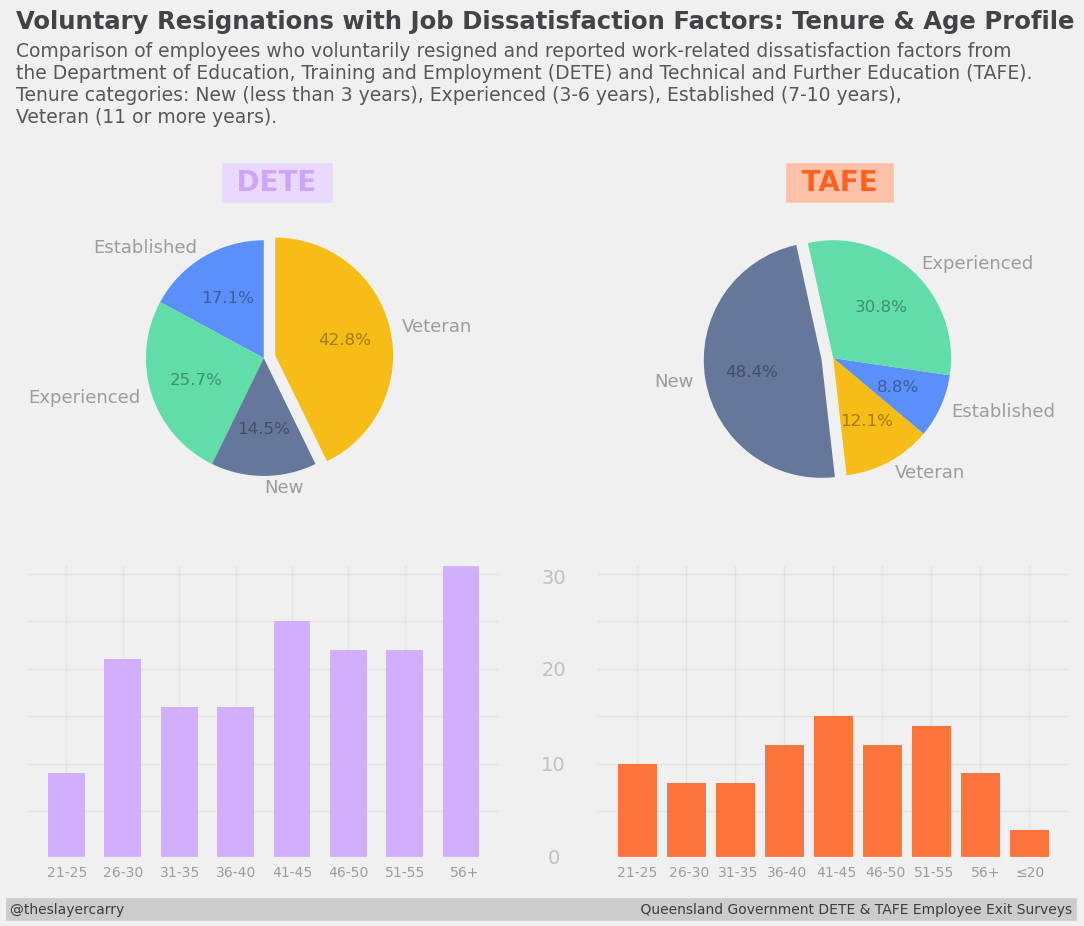

In [70]:
# Для данной визуализации мы будем использовать стиль `fivethirtyeight`
style.use('default')
style.use('fivethirtyeight')

plt.figure(figsize = (12, 8), dpi = 100)

# Первый ряд: Визуализация распределений категорий стажа среди сотрудников каждого университета

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 2, 3)
ax4 = plt.subplot(2, 2, 4)

#Круговые диаграммы:
my_colors = [
    '#5B8FF9',
    '#61DDAA',
    '#65789B',
    '#F6BD16'
]

# Отдельно выделить 4 элемент на круговой диаграмме DETE
explode_DETE = (0, 0, 0, 0.1) 
wedges_pie1, texts_pie1, autotexts_pie1 = ax1.pie(DETE_category_group.values, labels = DETE_category_group.index, colors = my_colors, explode = explode_DETE, autopct="%1.1f%%", startangle=90)

# прозрачность для названий категорий
for text in texts_pie1:
    text.set_alpha(0.35)
    text.set_fontsize(13)
# прозрачность для процентов
for autotext in autotexts_pie1:
    autotext.set_alpha(0.35)
    autotext.set_fontsize(12)


# Отдельно выделить 3 элемент на круговой диаграмме TAFE
explode_TAFE = (0, 0, 0.1, 0)
wedges_pie2, texts_pie2, autotexts_pie2 = ax2.pie(TAFE_category_group.values, labels = TAFE_category_group.index, colors = my_colors, explode = explode_TAFE, autopct="%1.1f%%", startangle=-40)

# прозрачность для названий категорий
for text in texts_pie2:
    text.set_alpha(0.35)
    text.set_fontsize(13)
# прозрачность для процентов
for autotext in autotexts_pie2:
    autotext.set_alpha(0.35)
    autotext.set_fontsize(12)
 

#Столбчатые диаграммы:
ax3.bar(DETE_age_group.index, DETE_age_group.values, width = 0.65, alpha = 0.86, color = '#cda5ff')
ax4.bar(TAFE_age_group.index, TAFE_age_group.values, width = 0.8, alpha = 0.86, color = '#ff611e')

# Добавление текста и других структурных элементов
#рисуем отметки на осях x:
x_coords_ax3 = [-0.35, 0.65, 1.65, 2.65, 3.65, 4.65, 5.65, 6.8]
x_coords_ax4 = [-0.42, 0.65, 1.65, 2.65, 3.65, 4.65, 5.65, 6.8, 7.71]
y_coords_ax3 = [9.35, 19.3, 29]

for age, x_coord in zip(DETE_age_group.index, x_coords_ax3):
    ax3.text(x = x_coord, y = -1.8, s = age, size = 10, alpha = 0.35)  
for age, x_coord in zip(TAFE_age_group.index, x_coords_ax4):
    ax4.text(x = x_coord, y = -1.8, s = age, size = 10, alpha = 0.35)

#рисуем отметки на оси y, начиная с 10:
for tick, y_coord in zip(range(10, 31, 10), y_coords_ax3):
    ax3.text(x = 8.42, y = y_coord, s = tick, size = 14, alpha = 0.20)
#отдельно рисуем 0, чтобы он был посередине
ax3.text(x = 8.53, y = -0.5, s = 0, size = 14, alpha = 0.20)

    
barh = [ax3, ax4]   
for ax in barh:
    ax.set_ylim(0, 31)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    #ax.axhline(y = 15, color = 'grey', alpha = 0.4, linewidth = 2.5)
    ax.grid(alpha = 0.3)

# Заголовок
ax1.text(x = -2.1, y = 2.8, s = 'Voluntary Resignations with Job Dissatisfaction Factors: Tenure & Age Profile', size = 17.5, weight = 'bold', color = '#242528', alpha = 0.85)

# Подзаголовок
ax1.text(x = -2.1, y = 2, s = '''Comparison of employees who voluntarily resigned and reported work-related dissatisfaction factors from
the Department of Education, Training and Employment (DETE) and Technical and Further Education (TAFE). 
Tenure categories: New (less than 3 years), Experienced (3-6 years), Established (7-10 years), 
Veteran (11 or more years).''', size = 13.5, color = "#575757")


#Подписываем каждый график
ax1.text(-0.31, 1.425, ' DETE ', color = '#cda5ff', size = 20, weight = 'bold', backgroundcolor = '#ead9ff')
ax2.text(-0.35, 1.425, ' TAFE ', color = '#ff611e', size = 20, weight = 'bold', backgroundcolor = "#ffc1a7")

#Подпись создателя
ax3.text(-1, -5.7, s = "@theslayercarry" + 118*" " + "Queensland Government DETE & TAFE Employee Exit Surveys", backgroundcolor = '#cccccc', size = 10, alpha = 0.7)

plt.show()

### **Вывод:**
Среди сотрудников `DETE`, выразивших неудовлетворённость работой, наибольшую долю (42,8 %) составляют те, чей стаж превышает 11 лет. Возрастное распределение также смещено в сторону более старших возрастных групп: преобладают категории 41-45, 46-50, 51-55 и 56+ лет. Наиболее часто упоминаемыми причинами недовольства являются неудовлетворённость самой работой, отсутствие признания и нарушение баланса между профессиональной и личной жизнью. Такое сочетание факторов может свидетельствовать о накоплении неудовлетворённости у сотрудников с длительным стажем и возможных изменениях условий труда с течением времени. При этом имеющиеся данные не позволяют сделать однозначный вывод об ухудшении условий труда, поскольку отсутствует информация о динамике показателей и структуре всего персонала.

В `TAFE` среди сотрудников, выразивших неудовлетворённость работой, наибольшую долю составляют те, чей стаж менее 3 лет – 48,4 %. При этом доля сотрудников со стажем 11 лет и более значительно ниже и составляет всего 12,1 %. Анализ возрастного распределения не выявил выраженного смещения в сторону какой-либо группы. Заметной зависимости уровня недовольства от данного фактора не наблюдается. Среди основных причин ухода сотрудники чаще всего отмечали общее недовольство и неудовлетворённость выполняемой работой. Полученные результаты позволяют предположить, что наиболее высокий уровень неудовлетворённости приходится на ранние этапы трудовой деятельности в организации. В числе потенциальных факторов, обусловливающих данную тенденцию, могут выступать:

- сложности адаптации новых сотрудников к рабочим процессам и корпоративной среде;
- особенности условий труда;
- специфика рабочего графика.

Указанные факторы могут оказывать существенное влияние на удержание персонала в первые годы работы. Для подтверждения выдвинутой гипотезы рекомендуется провести дополнительный анализ, включающий изучение общей структуры персонала с детализацией по стажу и возрасту, а также сопоставление этих данных с показателями текучести кадров и результатами оценки вовлечённости сотрудников.

С целью выявления зависимости между стажем работы и количеством одновременно обозначенных причин неудовлетворённости была построена диаграмма рассеяния. Визуализация позволяет оценить, прослеживается ли тенденция к росту количества причин неудовлетворённости с увеличением продолжительности работы в организации:

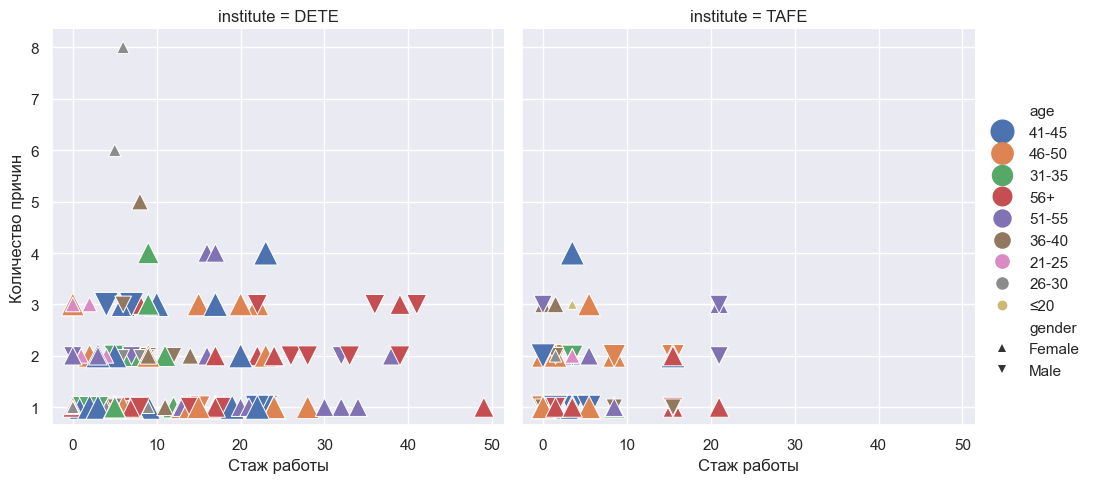

In [71]:
# Для данной визуализации мы будем использовать стиль seaborn
style.use('default')
sns.set_theme()

g = sns.relplot(
    data=combined[combined['dissatisfied'] > 0],
    x='institute_service',
    y='dissatisfied',
    hue='age',
    col='institute',
    size='age',
    sizes=(50, 300),
    style='gender',
    markers={
        'Male': "v",
        'Female': "^"
    },
    col_wrap=2
)

g.set_axis_labels("Стаж работы", "Количество причин")

plt.show()

In [72]:
one_more_reasons = combined[combined['dissatisfied'] > 0]
print(one_more_reasons['institute_service'].corr(one_more_reasons['dissatisfied']))

0.14827005604043275


### **Вывод:**
Коэффициент корреляции составил 0,15, что указывает на очень слабую положительную связь между показателями. Полученное значение не свидетельствует о наличии выраженной зависимости между стажем работы и количеством выбранных причин неудовлетворённости.

Одним из возможных объяснений может быть специфика заполнения анкеты: сотрудники, уходящие по собственному желанию, могли указывать только наиболее значимые причины, не рассматривая дополнительные варианты. Однако подтвердить данное предположение на основании имеющихся данных невозможно.

Также было установлено, что среди сотрудников, указавших 3 и более причин недовольства работой, в рассматриваемой выборке оказались только женщины. Это наблюдение может указывать на различия в подходе к заполнению анкеты, однако не позволяет сделать вывод о том, что одна из групп более подробно отражает причины недовольства. Для проверки данной гипотезы необходим дополнительный анализ распределения ответов с учётом пола и других характеристик сотрудников.